# Risoluzione tramite PINN

Sia il dominio associato all'artefatto in analisi (ovvero, la nostra amata roccia, che tanto ci ha fatto penare).

In questa fase, andremo a considerare sul dominio il modello associato al monitoraggio della temperatura sull'artefatto, con condizioni iniziali e condizioni al contorno fissate tramite i dati acquisiti con *sensori simulati*.

Effettuiamo gli import necessari

In [1]:
import json
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator
from copy import copy
from typing import List

from pina import LabelTensor, Condition, Plotter
from pina.geometry import Location, Union, Intersection, CartesianDomain
from pina.problem import SpatialProblem, AbstractProblem, TimeDependentProblem
from pina.operators import laplacian, grad
from pina.equation import FixedValue, Equation
from pina.solvers import PINN, SolverInterface
from pina.trainer import Trainer
from pina.model import FeedForward, ResidualFeedForward
from pina.callbacks import MetricTracker

from pytorch_lightning.callbacks import StochasticWeightAveraging

In [2]:
# Lavoriamo con i double
torch.set_default_dtype(torch.float64)

In [3]:
# Definizione punti spaziali al contorno per ogni istante temporale
space_boundary_data = 7

num_train = 2_000
num_test = 100

# Network variables
lear_rate = 5e-5
decay_rt = 1e-10

# Solver variables
epochs=30_000
batch=None
acc_str = 'gpu'

## Acquisizione del dominio e del contorno

In [4]:
# Opening JSON file
f = open('Files/Rock_triangoli_normali.json')

# returns JSON object as a dictionary
data = json.load(f)

# Chiusura del file
f.close()

print(len(data))
print("Chiavi:", data[0].keys())

print("Vertici totali:", len(data[0]["vertices"]))
print("Facce totali:", len(data[0]["faces"]))
print("Normali totali:", len(data[0]["normals"]))

1
Chiavi: dict_keys(['vertices', 'faces', 'normals'])
Vertici totali: 98
Facce totali: 192
Normali totali: 192


Calcoliamo il baricentro e alcune misure di interesse

In [5]:
# Calcoliamo il baricentro e la stima del raggio della sfera che comprende la roccia
# Calcolo baricentro e massimo
x_bar , y_bar, z_bar = 0, 0, 0
for dt in data:
    for el in dt["vertices"]:
        x, y, z = el
        x_bar += x
        y_bar += y
        z_bar += z
        if dt["vertices"].index(el) == 0:
            x_max_all, y_max_all, z_max_all = abs(x), abs(y), abs(z)
            x_max , y_max, z_max = x, y, z
            x_min , y_min, z_min = x, y, z
        else:
            x_max_all = max(x_max_all, abs(x))
            y_max_all = max(y_max_all, abs(y))
            z_max_all = max(z_max_all, abs(z))
            x_max = max(x_max, x)
            x_min = min(x_min, x)
            y_max = max(y_max, y)
            y_min = min(y_min, y)
            z_max = max(z_max, z)
            z_min = min(z_min, z)
tot_points = len(dt["vertices"])
x_bar /= tot_points
y_bar /= tot_points
z_bar /= tot_points
print("Baricentro:")
print(x_bar, y_bar, z_bar)
print("Massimi:")
print(x_max_all, y_max_all, z_max_all)
rho = math.sqrt((x_max_all-x_bar)**2 + (y_max_all-y_bar)**2 + (z_max_all-z_bar)**2)
print("Ampiezza:")
print(rho)

print(f"Intervallo x: [{x_min:.2f}, {x_max:.2f}]")
print(f"Intervallo y: [{y_min:.2f}, {y_max:.2f}]")
print(f"Intervallo z: [{z_min:.2f}, {z_max:.2f}]")

Baricentro:
-0.06567780430219611 0.006592731951374789 -0.06084773316979408
Massimi:
1.7598968744277954 1.832229733467102 1.6694382429122925
Ampiezza:
3.1079837399751282
Intervallo x: [-1.76, 1.42]
Intervallo y: [-1.80, 1.83]
Intervallo z: [-1.67, 1.63]


Acquisizione di una lista di dizionari con infomrazioni di interesse per ogni faccia di $\Gamma = \partial \Omega$

In [6]:
total_points_lst = list()

for dt in data:
    for i in range(len(dt["faces"])):
        idx_lst = copy(dt["faces"][i])
        x = [dt["vertices"][idx][0] for idx in idx_lst]
        y = [dt["vertices"][idx][1] for idx in idx_lst]
        z = [dt["vertices"][idx][2] for idx in idx_lst]
        total_points_lst.append(
            {
                "x" : copy(x),
                "y" : copy(y),
                "z" : copy(z),
                "xlim" : [min(x), max(x)],
                "ylim" : [min(y), max(y)],
                "zlim" : [min(z), max(z)]
            }
        )
        # Cleaning of lists
        x.clear(); y.clear(); z.clear()

### Acquisizione del contorno

Definiamo la classe per l'integrazione in **PINA** delle singole facce

In [7]:
class Face(Location):
    """
    Classe per campionare la singola faccia dell'acquisizione
    """

    def __init__(self, points : List[LabelTensor], limits : List[List[float]], margine : float = 2.):
        super().__init__()
        assert len(points) == 3, "The length of points should be 3"
        assert len(limits) == 3, "The length of limits should be 3"
        for el in limits:
            assert len(el) == 2, "The length of elements in limits should be 2"
        self.limits = limits
        self.margine = margine
        self.points = points
        self.variables = copy(self.points[0].labels)
        self.rho = self._calculate_rho()
        self.generate_vec1, self.generate_vec2, self.normal_vec = self._calculate_vectors()

    def _calculate_rho(self):
        x_bar_partial = 0; y_bar_partial = 0; z_bar_partial = 0
        for element in self.points:
            x_bar_partial += element.extract('x')
            y_bar_partial += element.extract('y')
            z_bar_partial += element.extract('z')
        x_bar_partial /= len(self.points)
        y_bar_partial /= len(self.points)
        z_bar_partial /= len(self.points)
        x_min, x_max = self.limits[0]
        y_min, y_max = self.limits[1]
        z_min, z_max = self.limits[2]
        maximum_x = max([abs(x_min), abs(x_max)])
        maximum_y = max([abs(y_min), abs(y_max)])
        maximum_z = max([abs(z_min), abs(z_max)])
        rho_partial = math.sqrt(
            (maximum_x + x_bar_partial)**2
            + (maximum_y + y_bar_partial)**2
            + (maximum_z + z_bar_partial)**2
        )
        return rho_partial * self.margine

    def _calculate_vectors(self):
        generate_vec1 = self.points[1] - self.points[0]
        generate_vec2 = self.points[2] - self.points[0]
        normal_vec = torch.cross(generate_vec1, generate_vec2).squeeze()
        return generate_vec1, generate_vec2, normal_vec

    def is_inside(self):
        pass

    def _my_is_inside(self, alpha : float, beta : float, gamma : float):
        if 0 <= alpha <= 1 and 0 <= beta <= 1 and 0 <= gamma <= 1:
            return True
        else:
            return False

    def sample(self, n, mode="random", variables="all"):
        sampled_points = list()

        while len(sampled_points) < n:
            lambda1 = 2*self.rho*torch.rand(1) - self.rho
            lambda2 = 2*self.rho*torch.rand(1) - self.rho
            point = (
                self.points[0]
                + lambda1*(self.generate_vec1/torch.norm(self.generate_vec1))
                + lambda2*(self.generate_vec2/torch.norm(self.generate_vec2))
            ).squeeze()
            gamma = (
                torch.cross(self.generate_vec1, point - self.points[0])
                @ self.normal_vec.T
                ) / (
                    self.normal_vec @ self.normal_vec.T
            )
            beta = (
                torch.cross(self.generate_vec2, point - self.points[0])
                @ self.normal_vec.T
                ) / (
                    self.normal_vec @ self.normal_vec.T
            )
            alpha = 1 - gamma - beta
            if self._my_is_inside(alpha, beta, gamma):
                point = alpha*self.points[0] + beta*self.points[1] + gamma*self.points[2]
                # Verifica che appartenga al piano
                if torch.abs((point - self.points[0]) @ self.normal_vec.T) < torch.finfo(torch.float64).eps:
                    sampled_points.append([point.squeeze()[0].item(), point.squeeze()[1].item(), point.squeeze()[2].item()])
        return LabelTensor(torch.tensor(sampled_points), labels=self.variables)

    def _plot_scatter(self, ax, pts):
        ax.scatter(
            pts.extract('x'),
            pts.extract('y'),
            pts.extract('z'),
            color='blue',
            alpha=0.5
        )

    def plot_samples(self, samples : LabelTensor, fig_size = (6, 6)):
        fig = plt.figure(figsize=fig_size)
        ax = plt.axes(projection="3d")
        for el in self.points:
            ax.scatter(el.extract('x'), el.extract('y'), el.extract('z'), c="r")
        self._plot_scatter(ax, samples)
        ax.set_title("Face")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        plt.show()

Ora acquisiamo $\Gamma$

In [8]:
variables = ['x', 'y', 'z']

total_faces_lst = list()

for dt in data:
    for i in range(len(dt["faces"])):
        idx_lst = copy(dt["faces"][i])
        x = copy([dt["vertices"][idx][0] for idx in idx_lst])
        y = copy([dt["vertices"][idx][1] for idx in idx_lst])
        z = copy([dt["vertices"][idx][2] for idx in idx_lst])
        input_values = [
            LabelTensor(
                torch.tensor([[x[0], y[0], z[0]]]),
                variables
            ),
            LabelTensor(
                torch.tensor([[x[1], y[1], z[1]]]),
                variables
            ),
            LabelTensor(
                torch.tensor([[x[2], y[2], z[2]]]),
                variables
            )
        ]
        limits = [
            copy([min(copy(x)), max(copy(x))]),
            copy([min(copy(y)), max(copy(y))]),
            copy([min(copy(z)), max(copy(z))])
        ]
        total_faces_lst.append(
            Face(
                copy(input_values),
                copy(limits)
            )
        )
        # Cleaning of lists
        input_values.clear(); limits.clear()
        x.clear(); y.clear(); z.clear()

/home/michael/miniconda3/envs/SissaUnisa/lib/python3.11/site-packages/torch/_tensor.py:1418: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /opt/conda/conda-bld/pytorch_1711403378171/work/aten/src/ATen/native/Cross.cpp:63.)
  ret = func(*args, **kwargs)


### Acquisizione del dominio $\Omega$

Anche in questo caso prima viene definita la classe per le singole facce e poi una classe Intersection personalizzata

In [9]:
class InternalFace(Location):
    """
    Classe per campionare la singola faccia dell'acquisizione
    """

    def __init__(self, points : List[LabelTensor], limits : List[List[float]], ampiezza : float, margine : float = 2.):
        super().__init__()
        assert len(points) == 3, "The length of points should be 3"
        assert len(limits) == 3, "The length of limits should be 3"
        for el in limits:
            assert len(el) == 2, "The length of elements in limits should be 2"
        self.limits = limits
        self.margine = margine
        self.ampiezza = ampiezza
        self.points = points
        self.variables = copy(self.points[0].labels)
        self.bar = self._calculate_bar()
        self.generate_vec1, self.generate_vec2, self.normal_vec = self._calculate_vectors()

    def _calculate_bar(self):
        in_bar = [0, 0, 0]
        len_bar = 3
        for elem in self.points:
            for i in range(len_bar):
                in_bar[i] += elem.tensor[0, i].item()
        bar = [in_bar[i]/3 for i in range(len_bar)]
        return LabelTensor(torch.tensor([bar]), labels=self.variables)

    def _calculate_vectors(self):
        generate_vec1 = self.points[1] - self.points[0]
        generate_vec2 = self.points[2] - self.points[0]
        normal_vec = torch.cross(generate_vec1, generate_vec2).squeeze()
        return generate_vec1, generate_vec2, normal_vec

    def is_inside(self, point : LabelTensor, check_border : bool =False):
        vet = point.tensor.squeeze() - self.bar.tensor.squeeze()
        if torch.dot(vet, self.normal_vec) <= 0:
            return True
        else:
            return False

    def sample(self, n, mode="random", variables="all"):
        sampled_points = list()

        while len(sampled_points) < n:
            # movimento generico nel piano
            lambda1 = 2*self.ampiezza*torch.rand(1) - self.ampiezza
            lambda2 = 2*self.ampiezza*torch.rand(1) - self.ampiezza
            # movimento generico nello spazio
            space_mov = 2*self.ampiezza*torch.rand(1)
            add_point = (
                self.bar.tensor
                + lambda1*(self.generate_vec1/torch.norm(self.generate_vec1))
                + lambda2*(self.generate_vec2/torch.norm(self.generate_vec2))
                - space_mov*self.normal_vec).tolist()
            point = LabelTensor(torch.tensor(add_point), labels=self.variables)
            if self.is_inside(point):
                sampled_points.append(add_point[0])
        return LabelTensor(torch.tensor(sampled_points), labels=self.variables)

    def _plot_scatter(self, ax, pts):
        ax.scatter(
            pts.extract('x'),
            pts.extract('y'),
            pts.extract('z'),
            color='blue',
            alpha=0.5
        )

    def plot_samples(self, ax, samples : LabelTensor, fig_size = (6, 6)):
        for el in self.points:
            ax.scatter(el.extract('x'), el.extract('y'), el.extract('z'), c="r")
        self._plot_scatter(ax, samples)
        ax.set_title("Face")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

In [10]:
class MyIntersection(Location):
    """
    Personalized intersection for rock
    """

    def __init__(self, faces : List[InternalFace], bar : LabelTensor, ampiezza : float):
        super().__init__()
        self.faces = faces
        self.bar = bar
        self.variables = copy(bar.labels)
        self.ampiezza = ampiezza

    def is_inside(self, point, check_border=False):
        results = [element.is_inside(point) for element in self.faces]
        return all(results)

    def sample(self, n, mode="random", variables="all"):
        sampled_points = list()

        while len(sampled_points) < n:
            theta = 2*torch.pi*torch.rand(1)
            gamma = 2*torch.pi*torch.rand(1)
            rho = 2*self.ampiezza*torch.rand(1)
            x = self.bar.tensor[0, 0].item() + rho*torch.sin(theta)*torch.cos(gamma)
            y = self.bar.tensor[0, 1].item() + rho*torch.sin(theta)*torch.sin(gamma)
            z = self.bar.tensor[0, 2].item() + rho*torch.cos(theta)
            lst = [x.item(), y.item(), z.item()]
            point = LabelTensor(torch.tensor([[x.item(), y.item(), z.item()]]), labels=self.variables)
            if self.is_inside(point):
                sampled_points.append(copy(lst))
            lst.clear()
        return LabelTensor(torch.tensor(sampled_points), labels=self.variables)

    def sample_fixed_value(self, n : int, variable : str, fixed_value : float):
        if variable not in self.variables:
            raise ValueError("Input variable not in the set of domain variables")
        if variable == self.variables[0]:
            return self._sampled_fixed_x(n, fixed_value)
        if variable == self.variables[1]:
            return self._sampled_fixed_y(n, fixed_value)
        if variable == self.variables[2]:
            return self._sampled_fixed_z(n, fixed_value)

    def _sampled_fixed_x(self, n :int, fixed_value_x : float) -> LabelTensor:
        sampled_points = list()

        while len(sampled_points) < n:
            y = torch.distributions.Uniform(-self.ampiezza, self.ampiezza).sample((1, 1))
            z = torch.distributions.Uniform(-self.ampiezza, self.ampiezza).sample((1, 1))
            control = [fixed_value_x, y, z]
            if self.is_inside(LabelTensor(torch.tensor([control]), self.variables)):
                sampled_points.append(copy(control))
            control.clear()
        return LabelTensor(torch.tensor(sampled_points), self.variables)

    def _sampled_fixed_y(self, n :int, fixed_value_y : float) -> LabelTensor:
        sampled_points = list()

        while len(sampled_points) < n:
            x = torch.distributions.Uniform(-self.ampiezza, self.ampiezza).sample((1, 1))
            z = torch.distributions.Uniform(-self.ampiezza, self.ampiezza).sample((1, 1))
            control = [x, fixed_value_y, z]
            if self.is_inside(LabelTensor(torch.tensor([control]), self.variables)):
                sampled_points.append(copy(control))
            control.clear()
        return LabelTensor(torch.tensor(sampled_points), self.variables)

    def _sampled_fixed_z(self, n :int, fixed_value_z : float) -> LabelTensor:
        sampled_points = list()

        while len(sampled_points) < n:
            x = torch.distributions.Uniform(-self.ampiezza, self.ampiezza).sample((1, 1))
            y = torch.distributions.Uniform(-self.ampiezza, self.ampiezza).sample((1, 1))
            control = [x, y, fixed_value_z]
            if self.is_inside(LabelTensor(torch.tensor([control]), self.variables)):
                sampled_points.append(copy(control))
            control.clear()
        return LabelTensor(torch.tensor(sampled_points), self.variables)

Definiamo $\Omega$

In [11]:
total_int_faces_lst = list()

for dt in data:
    for i in range(len(dt["faces"])):
        idx_lst = copy(dt["faces"][i])
        x = copy([dt["vertices"][idx][0] for idx in idx_lst])
        y = copy([dt["vertices"][idx][1] for idx in idx_lst])
        z = copy([dt["vertices"][idx][2] for idx in idx_lst])
        input_values = [
            LabelTensor(
                torch.tensor([[x[0], y[0], z[0]]]),
                variables
            ),
            LabelTensor(
                torch.tensor([[x[1], y[1], z[1]]]),
                variables
            ),
            LabelTensor(
                torch.tensor([[x[2], y[2], z[2]]]),
                variables
            )
        ]
        limits = [
            copy([min(copy(x)), max(copy(x))]),
            copy([min(copy(y)), max(copy(y))]),
            copy([min(copy(z)), max(copy(z))])
        ]
        total_int_faces_lst.append(
            InternalFace(
                copy(input_values),
                copy(limits),
                ampiezza=rho
            )
        )
        # Cleaning of lists
        input_values.clear(); limits.clear()
        x.clear(); y.clear(); z.clear()

bar = LabelTensor(torch.tensor([[x_bar, y_bar, z_bar]]), labels=variables)

### Definizione classe TemporalBlender

In [12]:
class TemporalBlender(Location):

    def __init__(self, spatial_domain : Location, limiti_temporali : List[float]):
        super().__init__()
        self.spatial_domain = spatial_domain
        self.t_min, self.t_max = limiti_temporali
        self.variables = copy(spatial_domain.variables)
        self.variables.append('t')

    def is_inside(self, pts, check_border = True):
        spat_pts = pts.extract(self.variables[:-1])
        temp_pts = pts.extract(['t']).tensor.item()
        if check_border:
            if self.spatial_domain.is_inside(spat_pts) and self.t_min <= temp_pts <= self.t_max:
                return True
        if not check_border:
            if self.spatial_domain.is_inside(spat_pts) and self.t_min < temp_pts < self.t_max:
                return True
        return False

    def sample(self, n : int, mode="random", variables="all"):
        sampled_points = list()

        while len(sampled_points) < n:
            t_value = (self.t_max - self.t_min)*torch.rand(1) + self.t_min
            pts = copy(self.spatial_domain.sample(1, mode, variables).squeeze().tolist())
            pts.append(t_value)
            sampled_points.append(copy(pts))
            pts.clear()

        return LabelTensor(torch.tensor(sampled_points), self.variables)

## Definizione del problema tramite il modulo `Problem` di PINA

Consideriamo il modello di diffusione del calore

$$
\begin{equation}
  \begin{cases}
    \frac{\partial T}{\partial t} \left( t, x, y, z \right) - \Delta T \left( t, x, y, x \right) = 0 & \left( t, x, y, z \right) \in \left[0, 1 \right] \times \Omega \\
    T \left( 0, x, y, z \right) = T_0 & \left( x, y, z \right) \in \Omega\\
    T \left( t, x, y, z \right) = \mathrm{data} & \left(t, x, y, z \right) \in \left(0, 1 \right] \times \partial \Omega
  \end{cases}
  \tag{1}
\end{equation}
$$

A tale scopo carichiamo i dati approssimati tramite una NN relativi alle condizioni iniziali e al contorno e definiamo il problema tramite la classe `Problem` di **PINA**.

In [13]:
# Acquisizione dati iniziali e al contorno
df = pd.read_csv("Files/0_Base_TempData.csv", sep=";")

print(df.keys())

Index(['Datetime', 'Temperature_C'], dtype='object')


Impostiamo la temperatura iniziale e le condizioni al contorno

In [14]:
T_initial = torch.tensor(df["Temperature_C"][0], dtype = torch.float64)
data_boundary = torch.tensor(df["Temperature_C"], dtype = torch.float64).reshape((df["Temperature_C"].shape[0], 1))

Definiamo i sample sulla superficie

In [15]:
boundary_surface = Union(total_faces_lst)
space_boundary_samples = boundary_surface.sample(space_boundary_data)

/home/michael/miniconda3/envs/SissaUnisa/lib/python3.11/site-packages/torch/_tensor.py:1418: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1711403378171/work/aten/src/ATen/native/TensorShape.cpp:3637.)
  ret = func(*args, **kwargs)


Adattiamo i dati alle boundary, integrando i dati temporali con quelli spaziali

In [ ]:
LT_lst = list()
time = np.linspace(0, 1, data_boundary.shape[0])
T_boundary = list()

for i in range(time.shape[0]):
  for sp_el in space_boundary_samples:
    LT_lst.append([sp_el.tensor[0].item(), sp_el.tensor[1].item(), sp_el.tensor[2].item(), time[i]])
    T_boundary.append([df["Temperature_C"][i]])

data_boundary = LabelTensor(torch.tensor(LT_lst), ["x", "y", "z", "t"])
Temp_boundary = LabelTensor(torch.tensor(T_boundary), labels=["u"])

### Definizione del problem

In [17]:
class Heat(SpatialProblem, TimeDependentProblem):

    input_variables = ['x','y','z','t']
    output_variables = ['u']
    spatial_domain = MyIntersection(
        total_int_faces_lst,
        bar=bar,
        ampiezza=rho
    )
    temporal_domain = CartesianDomain(
        {
            't' : [0, 1]
        }
    )

    # Definiamo la funzione per il residuo
    def fix_parab_equation(input_, output_):
        u_t = grad(output_, input_, components=['u'], d=['t'])
        my_lapl = laplacian(output_, input_, components=['u'], d=['x', 'y', 'z'])
        return u_t - my_lapl

    conditions = {
        'Gamma' : Condition(
            input_points=data_boundary,
            output_points=Temp_boundary
        ),
        'Omega' : Condition(
            location=TemporalBlender(
                spatial_domain=spatial_domain,
                limiti_temporali=[0., 1.]
            ),
            equation=Equation(fix_parab_equation)
        )
    }

    conditions['Gamma'].data_weight = .33
    conditions['Omega'].data_weight = .77


# Inizializzazione dell'oggetto problem
problem = Heat()
print(problem.input_variables)
print(problem.output_variables)

['x', 'y', 'z', 't']
['u']


Acquisizione dati di training e testing

In [18]:
df_train_tot = pd.read_csv("Files/2_Base_FEM_Train.csv", sep=";", index_col=False).iloc[:, :4]
ref_train_df = pd.read_csv("Files/2_Base_FEM_Train.csv", sep=";", index_col=False).iloc[:, 4]
df_test_tot = pd.read_csv("Files/2_Base_FEM_Test.csv", sep=";", index_col=False).iloc[:, :4]
ref_test_df = pd.read_csv("Files/2_Base_FEM_Test.csv", sep=";", index_col=False).iloc[:, 4]

df_train = df_train_tot.sample(num_train, replace=False)
df_test = df_test_tot.sample(num_test, replace=False)

samples_train = LabelTensor(
    torch.tensor(df_train.values),
    problem.input_variables
)

samples_test = LabelTensor(
    torch.tensor(df_test.values),
    problem.input_variables
)

Discretizzazione del dominio e del bordo

In [19]:
# Discretizzazione del contorno e del dominio
problem.discretise_domain(
    n=1,
    mode='random',
    locations=['Omega']
)
problem.input_pts['Omega'] = samples_train

## Costruzione del modello, del solver e del trainer in PINA.

Introduciamo il modello con vincoli rigidi

In [20]:
class HardMLP(torch.nn.Module):

    def __init__(self, T_initial, *args, **kwargs):
        super().__init__()
        self.T_initial = T_initial

        self.layers = ResidualFeedForward(*args, **kwargs)

    # Nel metodo forward implementiamo il vincolo rigido
    def forward(self, x):
        return self.T_initial + x.extract("t")*self.layers(x)

In [21]:
# Modello
model = HardMLP(T_initial, input_dimensions=4,output_dimensions=1,n_layers=5,inner_size=400)
# Solver
pinn=PINN(
    problem=problem,
    model=model,
    optimizer_kwargs={
        'lr' : lear_rate,
        'weight_decay' : decay_rt
    }
)

"""# Impostazioni prese da Raissi et al.
pinn=PINN(
    problem=problem,
    model=model,
    optimizer=torch.optim.LBFGS,
    optimizer_kwargs={
        'lr' : 1e-3,
        'max_iter' : 50,
        'max_eval' : 50000,
        'tolerance_change' : 1. * torch.finfo(torch.float64).eps#,
        #'line_search_fn' : "strong_wolfe"
    }
)"""

# Trainer
trainer=Trainer(
    solver=pinn,
    max_epochs=epochs,
    batch_size=batch,
    accelerator=acc_str,
    precision='64-true',
    callbacks=[MetricTracker(), StochasticWeightAveraging(swa_lrs=lear_rate, swa_epoch_start=0.80)]
)

# Addestramento
trainer.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/michael/miniconda3/envs/SissaUnisa/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch

Epoch 23998: 100%|██████████| 2/2 [00:00<00:00, 18.27it/s, v_num=25, Omega_loss=0.00113, mean_loss=0.00129, Gamma_loss=0.00748]  

Swapping scheduler `ConstantLR` for `SWALR`


Epoch 29999: 100%|██████████| 2/2 [00:00<00:00, 18.19it/s, v_num=25, Omega_loss=0.00126, mean_loss=0.00125, Gamma_loss=0.00624]  

`Trainer.fit` stopped: `max_epochs=30000` reached.


Epoch 29999: 100%|██████████| 2/2 [00:00<00:00, 14.90it/s, v_num=25, Omega_loss=0.00126, mean_loss=0.00125, Gamma_loss=0.00624]


Residuo sui punti di testing

In [22]:
residual = torch.mean(model(samples_test))
residual_real = ref_train_df.values.mean()
#solver.neuralnet -> vedi docu pina
print(f"PINN: Media della temperatura sul test: {residual.tensor.item(): .2e}")
print(f"FEM:  Media della temperatura sul test: {residual_real: .2e}")

PINN: Media della temperatura sul test:  2.10e+01
FEM:  Media della temperatura sul test:  2.22e+01


Errore rispeto a soluzione di riferimento

In [23]:
rif_train_ts = LabelTensor(
    torch.tensor(ref_train_df.values, dtype=torch.float64),
    labels=['u']
)
rif_test_ts = LabelTensor(
    torch.tensor(ref_test_df.values, dtype=torch.float64),
    labels=['u']
)

assolute_train =  torch.linalg.norm(
    pinn.neural_net(samples_train) - rif_train_ts, ord=2)

relative_train = assolute_train / torch.linalg.norm(rif_train_ts, ord=2)

assolute_test = torch.linalg.norm(
    pinn.neural_net(samples_test) - rif_test_ts, ord=2)

relative_test = assolute_test / torch.linalg.norm(rif_test_ts, ord=2)

print("TRAIN")
print(f"Assoluto = {assolute_train.tensor.item():.2e}\tRelativo = {relative_train.tensor.item():.2e}")

print("TEST")
print(f"Assoluto = {assolute_test.tensor.item():.2e}\tRelativo = {relative_test.tensor.item():.2e}")

TRAIN
Assoluto = 7.82e+03	Relativo = 3.53e+00
TEST
Assoluto = 1.69e+03	Relativo = 7.63e-01


Salvataggio errori

In [24]:
errors = {
    "train" : {
        "assoluto" : assolute_train.tensor.item(),
        "relativo" : relative_train.tensor.item()
    },
    "test" : {
        "assoluto" : assolute_test.tensor.item(),
        "relativo" : relative_test.tensor.item()
    }
}

with open("Files/3_Base_Errori.json", "w") as fp:
    json.dump(errors, fp)

## Grafico dei risultati

In [25]:
class MyPlotter(Plotter):
    """
    Class for 2D plots in 3D domains
    """

    def __init__(self, domain : Location, problem : AbstractProblem, solver : SolverInterface):
        super().__init__()
        self.domain = domain
        self.problem = problem
        self.variables = problem.input_variables
        self.solver = solver

    def _fixed_x_plot(self, fixed_values : List[float], lim_y : List[float], lim_z : List[float], temporal_value : float, res :int = 50, N_levels = 10):
        if not isinstance(fixed_values, list):
            fixed_values = [fixed_values]
        y = torch.linspace(lim_y[0], lim_y[1], res)
        z = torch.linspace(lim_z[0], lim_z[1], res)
        Y, Z = torch.meshgrid(y, z)
        for val in fixed_values:
            idx = fixed_values.index(val)
            input = LabelTensor(torch.cat([val*torch.ones((res*res, 1)), Y.reshape(res*res, 1), Z.reshape(res*res, 1), temporal_value*torch.ones((res*res, 1))], axis=-1), self.variables)
            input_mask = [self.domain.is_inside(input[i].extract(['x', 'y', 'z'])) for i in range(res*res)]
            preds = self.solver.forward(input)

            min_value_pred, max_value_pred = torch.min(preds), torch.max(preds)
            out_value_pred = min_value_pred.tensor.item() - (max_value_pred.tensor.item() - min_value_pred.tensor.item())

            new_preds = [preds[i].tensor.item() if input_mask[i] else out_value_pred for i in range(res*res)]
            new_preds = torch.tensor(new_preds).reshape(res, res)

            locator = MaxNLocator(N_levels + 1, min_n_ticks=N_levels)
            lev_pred = locator.tick_values(out_value_pred, max_value_pred.detach().numpy())

            fig, ax = plt.subplots(1, 1, figsize=(6, 6))
            cb = ax.contourf(Y, Z, new_preds.detach().numpy(), levels=lev_pred[1:])
            fig.colorbar(cb, ax=ax)
            ax.set_title(f"Approximated Solution ($x = {val:1.2f}$)")
            ax.set_xlabel("$y$")
            ax.set_ylabel("$z$")
            plt.show()

Definizione dell'interno del dominio

In [26]:
inside = MyIntersection(
    total_int_faces_lst,
    bar=bar,
    ampiezza=rho
)

my_pl = MyPlotter(inside, problem, pinn)

### Plot delle loss: mean_loss, Omega e sui dati

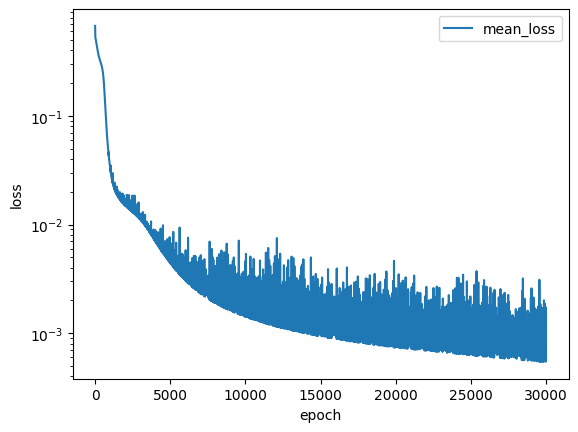

In [27]:
my_pl.plot_loss(
    trainer=trainer,
    metrics=['mean_loss'],
    label='mean_loss',
    logy=True
)

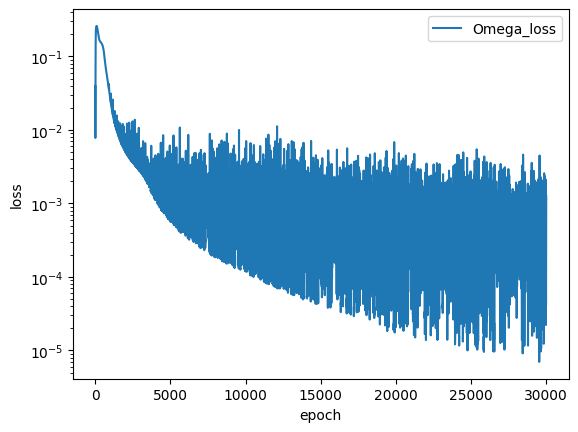

In [28]:
my_pl.plot_loss(
    trainer=trainer,
    metrics=['Omega_loss'],
    label='Omega_loss',
    logy=True
)

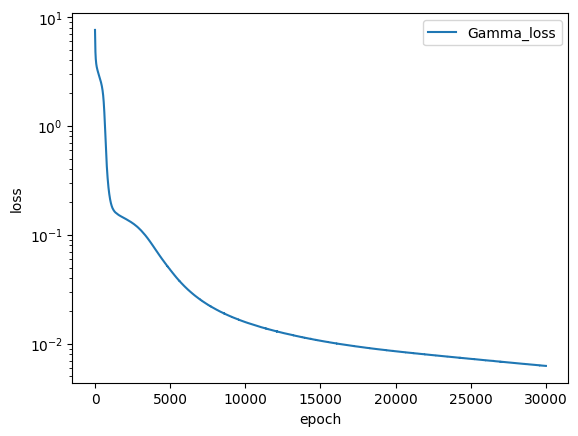

In [29]:
my_pl.plot_loss(
    trainer=trainer,
    metrics=['Gamma_loss'],
    label='Gamma_loss',
    logy=True
)

### Plot per x fissata

/home/michael/miniconda3/envs/SissaUnisa/lib/python3.11/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1711403378171/work/aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


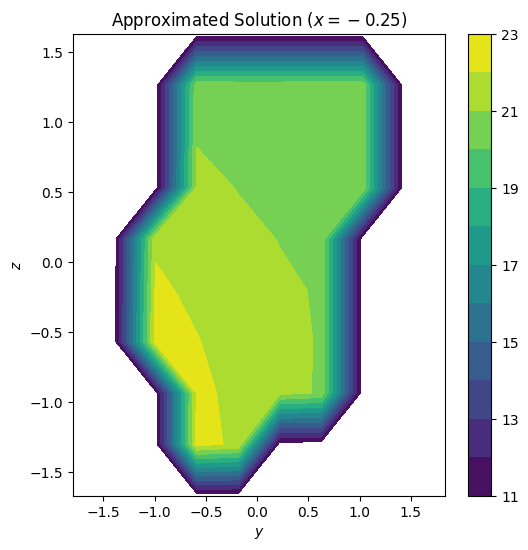

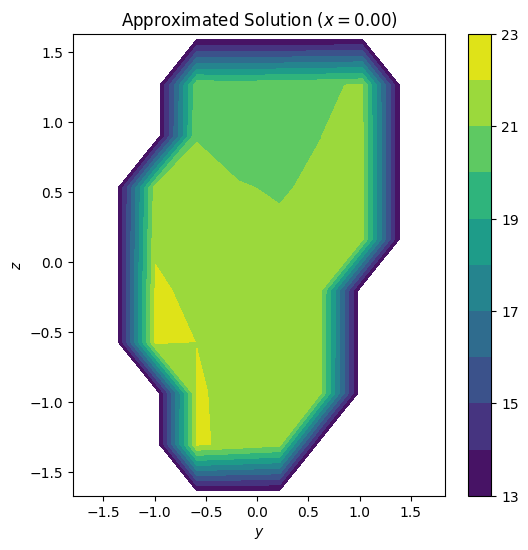

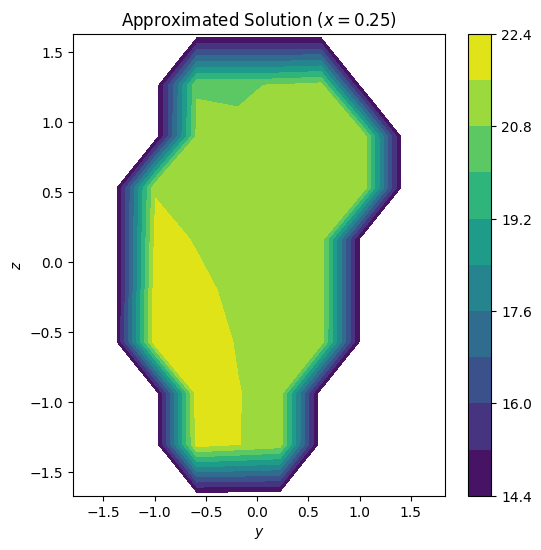

In [30]:
res = 10
fixed_x = [-.25, 0., .25]
lim_y = [y_min, y_max]
lim_z = [z_min, z_max]
my_pl._fixed_x_plot(fixed_x, res=res, lim_y=lim_y, lim_z=lim_z, temporal_value=0.8)

## Salvataggio del Trainer

In [31]:
import dill

def save_state(object_, file_name):
    """
    Saving python object as a pkl file
    """
    with open(file_name + ".pkl", "wb") as file_:
        dill.dump(object_, file_)

def load_state(file_name):
    """
    Load object saved attributes from file_name
    """
    return dill.load(open(file_name, "rb"))

In [32]:
save_state(trainer, "Files/3_Base_pinn_temp")

In [33]:
# Esempio load
loaded_trainer = load_state("Files/3_Base_pinn_temp.pkl")

out_prova = loaded_trainer.solver.neural_net(LabelTensor(torch.tensor([[0, 0.1, 0.2, 0.3]]), labels=["x", "y", "z", "t"]))
print(out_prova)

labels(['u'])
LabelTensor([[[20.1177]]], grad_fn=<AliasBackward0>)
